# Cosmic-muon flux through the KingCRAB fiducial volume

This notebook estimates the bare-sky atmospheric-muon rate through the cylindrical gas volume between the **cathode mesh** and the **EL-gap boundary mesh**.

The fiducial geometry is:

- radius: $R=0.16\,\mathrm{m}$
- length: $L=0.84\,\mathrm{m}$
- horizontal cylinder axis

## 1. Import the numerical tools

In [1]:
# Locate the repository when Jupyter starts in Notebooks/.
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'Notebooks': PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

from SRC.KingCRAB.muon_flux import (CylinderGeometry as Geometry, cos_theta_star, guan_intensity, projected_area_m2, energy_integral, azimuth_integrated_area, calculate, integrate_over_energy, integrate_area_over_azimuth, calculate_results)

import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

## 2. Enter the KingCRAB fiducial geometry

These are plain floating-point variables measured in metres.

The volume and vertical projected area follow from

$$V=\pi R^2L, \qquad A_{\rm vertical}=2RL=DL.$$

In [2]:
RADIUS_M = 0.16
LENGTH_M = 0.84

volume_m3 = np.pi * RADIUS_M**2 * LENGTH_M
vertical_projected_area_m2 = 2.0 * RADIUS_M * LENGTH_M

print(f"Fiducial volume = {volume_m3:.6f} m^3")
print(f"Vertical projected area = {vertical_projected_area_m2:.6f} m^2")

Fiducial volume = 0.067557 m^3
Vertical projected area = 0.268800 m^2


## 3. Define the surface-muon spectrum

We use the modified Gaisser parameterization from Guan *et al.* (2015). The function `guan_intensity(E, theta)` returns

$$I_\mu(E,\theta)=\frac{dN}{dA_\perp\,dt\,d\Omega\,dE}$$

in units of $\mathrm{m^{-2}\,s^{-1}\,sr^{-1}\,GeV^{-1}}$. Here:

- `energy_gev` is the muon energy in GeV;
- `theta_rad` is the zenith angle in radians, with $\theta=0$ vertically downward;
- the area is perpendicular to the muon's trajectory.

The five `P` numbers are published fit parameters used to correct the production angle near the horizon. They are constants, not KingCRAB parameters.

In [3]:
P1 = 0.102573
P2 = -0.068287
P3 = 0.958633
P4 = 0.0407253
P5 = 0.817285

## 4. Calculate the cylinder's projected area

The detector does not present the same silhouette to every muon direction. For a horizontal cylinder, define

$$q=|\sin\theta\cos\phi|,$$

where $\phi$ is azimuth measured relative to the cylinder axis. The exact projected area is

$$A_\perp(\theta,\phi)=\pi R^2q+2RL\sqrt{1-q^2}.$$

The first term is the projected endcap; the second is the projected side. Because this is already an area perpendicular to the trajectory, we do **not** multiply the final detector-rate integral by another $\cos\theta$.

In [4]:
print("Area seen by a vertical muon:", projected_area_m2(0.0, 0.0), "m^2")
print("Area seen along the cylinder axis:", projected_area_m2(np.pi/2, 0.0), "m^2")

Area seen by a vertical muon: 0.65274063 m^2
Area seen along the cylinder axis: 0.1829213999541967 m^2


## 5. Build the numerical integrals

The total rate is

$$R_\mu=\int_{E_{\min}}^{E_{\max}}dE\int_0^{2\pi}d\phi\int_0^{\pi/2}d\theta\;I_\mu(E,\theta)A_\perp(\theta,\phi)\sin\theta.$$

The factor $\sin\theta$ comes from the solid-angle element $d\Omega=\sin\theta\,d\theta\,d\phi$.

We integrate energy using `log_energy = ln(E)`. This is numerically stable because the muon spectrum spans many orders of magnitude. Since $dE=E\,d\ln E$, the code multiplies the integrand by `energy_gev`.

`moment=0` integrates the number rate. `moment=1` inserts one extra factor of energy, allowing us to calculate $\langle E\rangle$.

In [5]:
ENERGY_MAX_GEV = 1.0e5

## 6. Calculate the physical quantities

`calculate_results` returns an ordinary Python dictionary. For example, the rate is retrieved with `results["rate_per_second"]`.

The horizontal-plane flux contains a $\cos\theta$ because it refers to a horizontal sheet rather than the cylinder's directional silhouette. It is included as a sanity check against the familiar value near $1\,\mathrm{cm^{-2}\,min^{-1}}$.

The mean chord length uses Cavalieri's principle:

$$\langle\ell\rangle=\frac{V\int I_\mu\,dE\,d\Omega}{R_\mu}. $$

## 7. Run the baseline calculation

The baseline integrates from $10\,\mathrm{MeV}=0.01\,\mathrm{GeV}$ upward. This is a model cutoff, not an electronics threshold. An indoor-overburden calculation would suppress many of the low-energy and highly inclined muons before they reach KingCRAB.

In [6]:
results = calculate_results(energy_min_gev=0.01)

print(f"Muon rate = {results['rate_per_second']:.3f} per second")
print(f"Muon rate = {results['rate_per_minute']:.1f} per minute")
print(f"Selected mean energy = {results['mean_energy_gev']:.3f} GeV")
print(f"Horizontal flux = {results['horizontal_flux_cm2_min']:.3f} cm^-2 min^-1")
print(f"Mean path through fiducial gas = {results['mean_chord_m']:.4f} m")

Muon rate = 118.678 per second
Muon rate = 7120.7 per minute
Selected mean energy = 6.816 GeV
Horizontal flux = 0.834 cm^-2 min^-1
Mean path through fiducial gas = 0.3827 m


## 8. Check sensitivity to the lower-energy cutoff

This cell repeats the full integration for four lower-energy limits. The surface model is least certain at low energy and near the horizon, so this is a useful sensitivity check.

In [7]:
energy_thresholds_gev = np.array([0.01, 0.10, 0.30, 1.00])
threshold_results = [calculate_results(value) for value in energy_thresholds_gev]

print("E_min [GeV]   rate [s^-1]   mean energy [GeV]   mean chord [m]")
for row in threshold_results:
    print(
        f"{row['energy_min_gev']:11.2f}"
        f"{row['rate_per_second']:15.3f}"
        f"{row['mean_energy_gev']:20.3f}"
        f"{row['mean_chord_m']:17.4f}"
    )

E_min [GeV]   rate [s^-1]   mean energy [GeV]   mean chord [m]
       0.01        118.678               6.816           0.3827
       0.10        115.051               7.029           0.3829
       0.30        107.627               7.501           0.3832
       1.00         87.024               9.127           0.3844


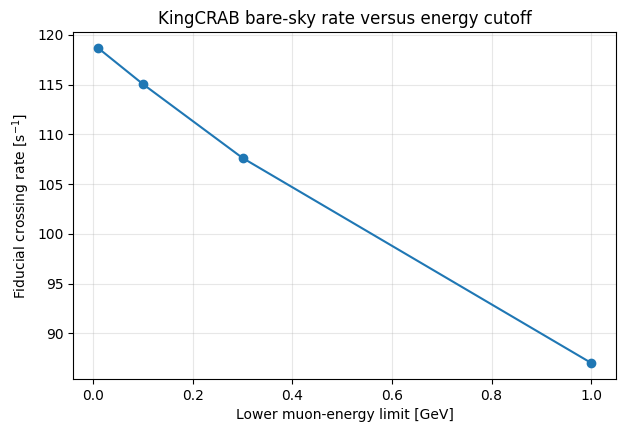

In [8]:
rates_per_second = [row["rate_per_second"] for row in threshold_results]

plt.figure(figsize=(7, 4.5))
plt.plot(energy_thresholds_gev, rates_per_second, marker="o")
plt.xlabel("Lower muon-energy limit [GeV]")
plt.ylabel("Fiducial crossing rate [s$^{-1}$]")
plt.title("KingCRAB bare-sky rate versus energy cutoff")
plt.grid(alpha=0.3)
plt.show()

## 9. Rule-of-thumb cross-check

For vertical muons, the cylinder looks like a rectangle with area $A=DL=2RL$. Multiplying by $1\,\mathrm{cm^{-2}\,min^{-1}}$ gives a deliberately simple estimate. It is not expected to exactly match the full spectrum-and-angle integral.

In [9]:
rule_of_thumb_flux_m2_s = 1.0e4 / 60.0
rule_of_thumb_rate_s = vertical_projected_area_m2 * rule_of_thumb_flux_m2_s

print(f"Simple projected-area estimate = {rule_of_thumb_rate_s:.3f} per second")
print(f"Full Guan calculation = {results['rate_per_second']:.3f} per second")

Simple projected-area estimate = 44.800 per second
Full Guan calculation = 118.678 per second


## 10. What this result does and does not include

This notebook calculates trajectories that intersect the ideal cathode-to-EL fiducial cylinder. It currently includes:

- a published sea-level energy and angular parameterization;
- the exact projected area of a finite horizontal cylinder;
- the full downward-hemisphere integration;
- energy-cutoff sensitivity and a rule-of-thumb check.

It does **not** yet include:

- roof, concrete floors, walls, or surrounding equipment;
- UTA elevation, pressure, weather, geomagnetic cutoff, or seasonal corrections;
- the pressure-vessel steel;
- charge recombination, attachment, EL production, optical collection, electronics thresholds, or analysis cuts.